<h1>
    <center>
        Customer Churn Analysis
    </center>
</h1>

In [251]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Connecting and importing data from SQL Database

In [133]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=CustomerChurn;"
    "Trusted_Connection=yes;"
)

In [134]:
#Creating dataframe
df_cust = pd.read_sql("SELECT * FROM db_customer", conn)
df_sub = pd.read_sql("SELECT * FROM db_subscription", conn)
df_sup = pd.read_sql("SELECT * FROM db_support", conn)
print(df_cust.shape)
df_cust.head()

(121, 8)


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,NaN


In [135]:
print(df_sub.shape)
df_sub.head()

(121, 11)


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [136]:
print(df_sup.shape)
df_sup.head()

(58, 6)


,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,None
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,None


## Data Cleaning

## Customer dataframe

In [137]:
df_cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  121 non-null    object 
 1   name        121 non-null    object 
 2   country     111 non-null    object 
 3   state       121 non-null    object 
 4   gender      121 non-null    object 
 5   dob         121 non-null    object 
 6   interests   71 non-null     object 
 7   pincode     14 non-null     float64
dtypes: float64(1), object(7)
memory usage: 7.7+ KB


In [138]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

## Column rename

In [139]:
df_cust = df_cust.rename(columns = {'name': 'customer_name'})

## Drop columns - interest and pincode

In [140]:
df_cust.drop(columns = ['interests','pincode'], inplace = True)

## Change data type - dob

In [141]:
df_cust['dob'] = pd.to_datetime(df_cust['dob'])

## Data standardization - gender

In [142]:
df_cust['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [143]:
df_cust['gender'] = df_cust['gender'].replace({'Men':'Male','Women':'Female'})

In [144]:
df_cust['gender'].unique()

array(['Male', 'Female'], dtype=object)

## Fixing Missing values

In [145]:
df_cust.isna().sum()

customerid        0
customer_name     0
country          10
state             0
gender            0
dob               0
dtype: int64

In [146]:
df_cust[df_cust['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
47,0030-DROFST,shiva,None,Tamil Nadu,Female,1997-03-23
77,0054-MLHTCL,raghvendra,None,Telangana,Male,1994-12-05
85,0064-UVWAIT,maya,None,Kathmandu,Female,1972-04-12
86,0057-GGZUXF,rakesh,None,Telangana,Female,1999-07-08
101,0013-IMGGCH,pooja,None,Kathmandu,Female,2003-10-26
104,0060-NDXDYI,ramesh,None,Gujarat,Male,1991-08-20
105,0053-PUSRAM,amit,None,Tamil Nadu,Female,1997-05-12


In [147]:
# Creating state → country map from non-null rows
state_country_mapping = df_cust.dropna(subset=['country']).set_index('state')['country'].to_dict()
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'India',
 'Uttar Pradesh': 'India',
 'Telangana': 'India',
 'Tamil Nadu': 'India',
 'West Bengal': 'India',
 'Punjab': 'India',
 'Kerala': 'India',
 'Gujarat': 'India'}

In [148]:
# Fill the missing country using State
df_cust['country'] = df_cust['country'].fillna(df_cust['state'].map(state_country_mapping))

In [149]:
df_cust[df_cust['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [150]:
#checking for duplicates
df_cust.duplicated().sum()

0

## Subscription table

In [151]:
df_sub.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [152]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               121 non-null    object 
 1   subscription_start_date  121 non-null    object 
 2   subscription_type        121 non-null    object 
 3   renewal_date             121 non-null    object 
 4   plan_type                121 non-null    object 
 5   contract_type            121 non-null    object 
 6   cancellation_date        34 non-null     object 
 7   cancellation_reason      34 non-null     object 
 8   monthly_charges          121 non-null    float64
 9   cltv                     121 non-null    int64  
 10  churn_score              121 non-null    int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 10.5+ KB


In [153]:
df_sub.isna().sum()

customerid                  0
subscription_start_date     0
subscription_type           0
renewal_date                0
plan_type                   0
contract_type               0
cancellation_date          87
cancellation_reason        87
monthly_charges             0
cltv                        0
churn_score                 0
dtype: int64

In [154]:
df_sub[df_sub['cancellation_date'].isna()]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5
...,...,...,...,...,...,...,...,...,...,...,...
115,0067-DZVTZM,2020-12-09,Refferal,2021-01-08,Standard,Monthly,None,None,17.99,1924,8
117,0067-IKDJTM,2021-04-25,Paid,2021-05-25,Premium,Monthly,None,None,22.99,827,22
118,0057-WCSEGR,2022-02-18,Refferal,2022-03-20,Standard,Monthly,None,None,16.99,815,1
119,0050-XOUJNJ,2023-01-19,Paid,2023-02-18,Standard,Monthly,None,None,16.99,254,37


In [155]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_sub[date_col] = df_sub[date_col].apply(pd.to_datetime)
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               121 non-null    object        
 1   subscription_start_date  121 non-null    datetime64[ns]
 2   subscription_type        121 non-null    object        
 3   renewal_date             121 non-null    datetime64[ns]
 4   plan_type                121 non-null    object        
 5   contract_type            121 non-null    object        
 6   cancellation_date        34 non-null     datetime64[ns]
 7   cancellation_reason      34 non-null     object        
 8   monthly_charges          121 non-null    float64       
 9   cltv                     121 non-null    int64         
 10  churn_score              121 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 10.5+ KB


In [156]:
#checking for duplicates
df_sub.duplicated().sum()

0

## Support Table

In [157]:
df_sup.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,None
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,None


In [158]:
df_sup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      58 non-null     object
 1   complaint_date  58 non-null     object
 2   escalations     58 non-null     object
 3   csat_score      58 non-null     int64 
 4   col_1           0 non-null      object
 5   comment         47 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.8+ KB


In [159]:
#Converting object type to date datatype
df_sup['complaint_date'] = pd.to_datetime(df_sup['complaint_date'])
df_sup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      58 non-null     object        
 1   complaint_date  58 non-null     datetime64[ns]
 2   escalations     58 non-null     object        
 3   csat_score      58 non-null     int64         
 4   col_1           0 non-null      object        
 5   comment         47 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 2.8+ KB


In [160]:
# dropping the column col_1 and comment
df_sup.drop(columns=['col_1','comment'], inplace=True)
df_sup.head(1)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60


In [161]:
#checking for duplicates
df_sup.duplicated().sum()

0

## Feature Engineering & Data Analysis

In [162]:
#Creating a Churn column
df_sub['churn'] = np.where(df_sub['cancellation_date'].notna(), 1,0)
df_sub.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [163]:
print(df_cust.shape)
print(df_sub.shape)
print(df_sup.shape)

(121, 6)
(121, 12)
(58, 4)


In [164]:
#Merging dataframes
df = (df_sub
      .merge(df_cust, on = 'customerid', how='left')
      .merge(df_sup, on = 'customerid', how='left'))

In [165]:
df.shape

(137, 20)

In [166]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


we can notice that the rows have increased after merge, we can also see multiple customer id recorded.

Need to find out which table has the same customerid's and fixt it 

In [167]:
print(df_cust.shape)
df_cust.nunique()

(121, 6)


customerid       121
customer_name     47
country            2
state             14
gender             2
dob              120
dtype: int64

In [168]:
print(df_sub.shape)
df_sub.nunique()

(121, 12)


customerid                 121
subscription_start_date    118
subscription_type            3
renewal_date               120
plan_type                    3
contract_type                2
cancellation_date           34
cancellation_reason          5
monthly_charges             10
cltv                       114
churn_score                 58
churn                        2
dtype: int64

In [169]:
print(df_sup.shape)
df_sup.nunique()

(58, 4)


customerid        42
complaint_date    57
escalations        2
csat_score        39
dtype: int64

Here we can notice that df_sup has multiple customer id

In [170]:
df_sup.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


creating a new feature to note number of complaints

In [173]:
df_sup['complaint_count'] = df_sup.groupby('customerid')['customerid'].transform('count')

In [175]:
df_sup.head()

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1


In [178]:
#dropping duplicates
df_sup = df_sup.sort_values('complaint_date').drop_duplicates('customerid', keep='last')
df_sup.shape

(42, 5)

we can merge the tables now 

In [179]:
#Merging dataframes
df = (df_sub
      .merge(df_cust, on = 'customerid', how='left')
      .merge(df_sup, on = 'customerid', how='left'))

In [180]:
df.shape

(121, 21)

### Exporting the dataframe

In [181]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [183]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


# Data Analysis

In [185]:
# Churn Rate
churn_rate = round(df['churn'].mean()*100,2)
print(f'Churn Rate: {churn_rate} %')

Churn Rate: 28.1 %


In [187]:
#Retention rate
retention_rate = 100-churn_rate
print(f'Retention Rate: {retention_rate} %')

Retention Rate: 71.9 %


In [193]:
#Churn by plan
churn_by_plan = df.groupby('plan_type')['churn'].mean().mul(100).round(2).astype(str) + '%'
churn_by_plan = churn_by_plan.reset_index(name='churn_rate_prct')
print(churn_by_plan)

  plan_type churn_rate_prct
0     Basic          38.46%
1   Premium           20.0%
2  Standard          25.53%


In [201]:
#Churn by state + sum(revenue) & count of users
churn_by_state = df.groupby('state').agg(
                                          churn = ('churn','sum'),
                                            Revenue = ('monthly_charges', 'sum'),
                                            Total_users = ('customerid','count')).reset_index()
churn_by_state.sort_values(by=['churn','Revenue'], ascending=False)

,state,churn,Revenue,Total_users
10,Tamil Nadu,4,390.89,11
6,Meghalaya,4,185.91,9
11,Telangana,4,173.89,11
0,Delhi,3,252.87,13
13,West Bengal,3,249.93,7
2,Karnataka,3,222.90,10
9,Rajasthan,3,185.93,7
7,Nagaland,2,209.91,9
5,Maharashtra,2,205.93,7
3,Kathmandu,2,127.90,10


In [194]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [204]:
#Churn by subscription type + sum(revenue) & count of users
churn_by_sub = df.groupby('subscription_type').agg(
                                                    churn = ('churn','sum'),
                                                    Total_revenue = ('monthly_charges','sum'),
                                                    Total_users = ('customerid','count')).reset_index()
churn_by_sub.sort_values(by=['Total_revenue'], ascending=False)

,subscription_type,churn,Total_revenue,Total_users
0,Organic,11,1354.51,49
1,Paid,11,754.62,38
2,Refferal,12,634.66,34


In [291]:
#Avg Revenue per user
ARU = round(df['monthly_charges'].mean(),2)
print(f'Average Revenue per user: {ARU}')

Average Revenue per user: 22.68


In [216]:
#calculate customer age
today = pd.Timestamp.today()

df['age'] = (today.year - df['dob'].dt.year - ((today.month < df['dob'].dt.month) | 
                                               ((today.month == df['dob'].dt.month)& (today.day < df['dob'].dt.day))))

In [217]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0,30
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,48
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,24
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,36


In [220]:
#Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
df['tenure_days'] = np.where(df['cancellation_date'].notna(),(df['cancellation_date'] - df['subscription_start_date']).dt.days,
(today - df['subscription_start_date']).dt.days)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1488 0


In [227]:
#Revenue at risk - revenue lost from churned users
revenue_at_risk = round(df.loc[df['churn']==1, 'monthly_charges'].sum(),2)
print("Revenue at Risk (Rs) =", revenue_at_risk)

Revenue at Risk (Rs) = 591.66


In [232]:
#Esclation Rate
escalation = round((df['escalations']=='Y').mean()*100,2)
print(f'Esclation Rate:{escalation} %')

Esclation Rate:19.83 %


In [235]:
#Avg Complaint Per User
avg_cmplt = round(df['complaint_count'].sum() /df['customerid'].nunique(),2)
print(f'Average Complaint per user: {avg_cmplt}')

Average Complaint per user: 0.48


In [241]:
#Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
corr_df = df[['escalations', 'churn']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.1


In [244]:
#Creating a column using existing col - Churn risk
conditions = [(df['churn_score'] < 50),
              (df['churn_score'] > 50) & (df['churn_score'] < 70),
              (df['churn_score'] > 70)]

options = ['low','mid','high']

df['churn_risk'] = np.select(conditions, options, default='unknown')

In [245]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,44,1991.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,30,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,48,1376.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,24,2666.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,36,419.0,high


## Visualization using Matplotlib

In [253]:
df_visuals = df.copy()

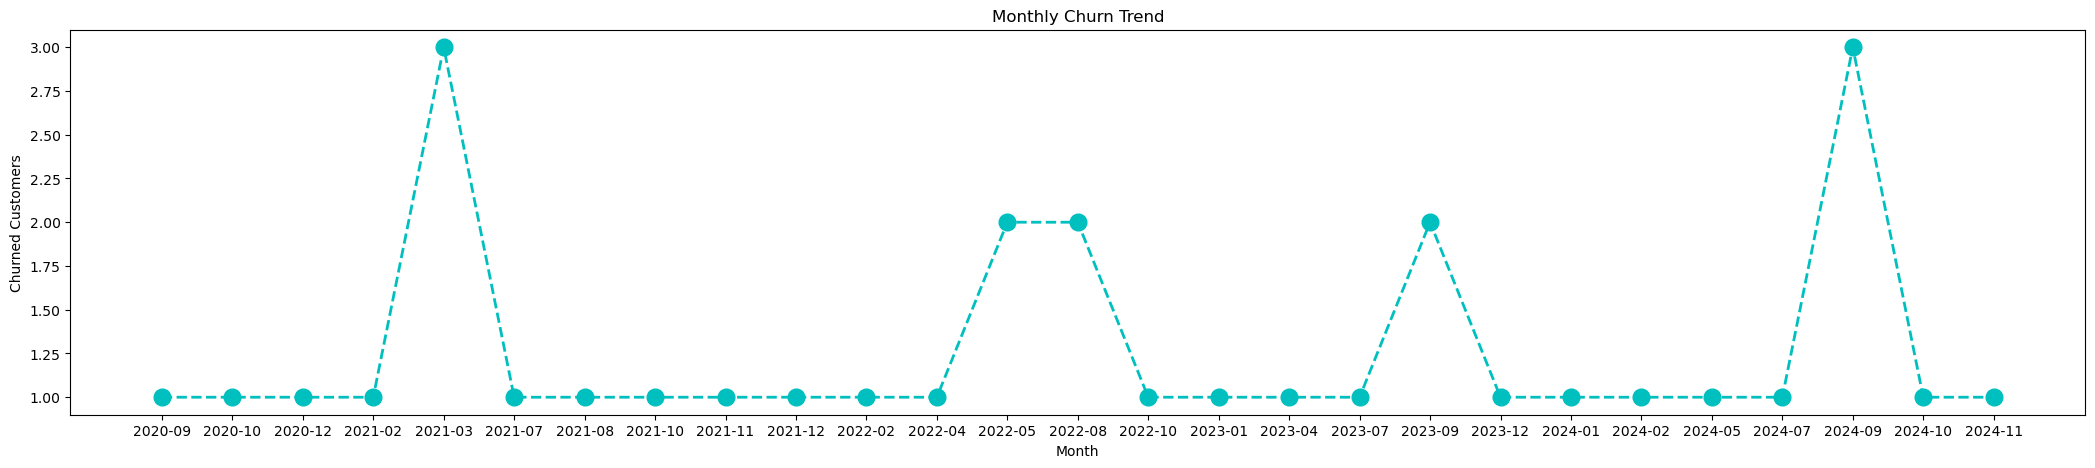

In [262]:
#Monthly Churn Trend (Time Series KPI)
df_visuals['cancellation_month'] = df_visuals['cancellation_date'].dt.to_period('M')

churn_trend = df_visuals[df_visuals['churn'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(26,5))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='c', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [247]:
df_visuals.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk'],
      dtype='object')

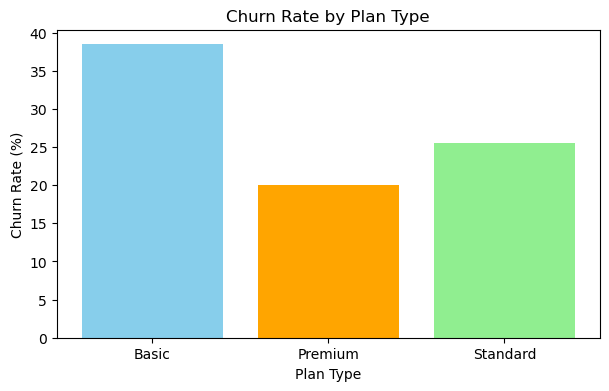

In [270]:
#Churn Rate by Plan type
churn_plan = round(df_visuals.groupby('plan_type')['churn'].mean()*100,2)

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color=['skyblue', 'orange', 'lightgreen'])

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

Text(0, 0.5, 'Churn Rate %')

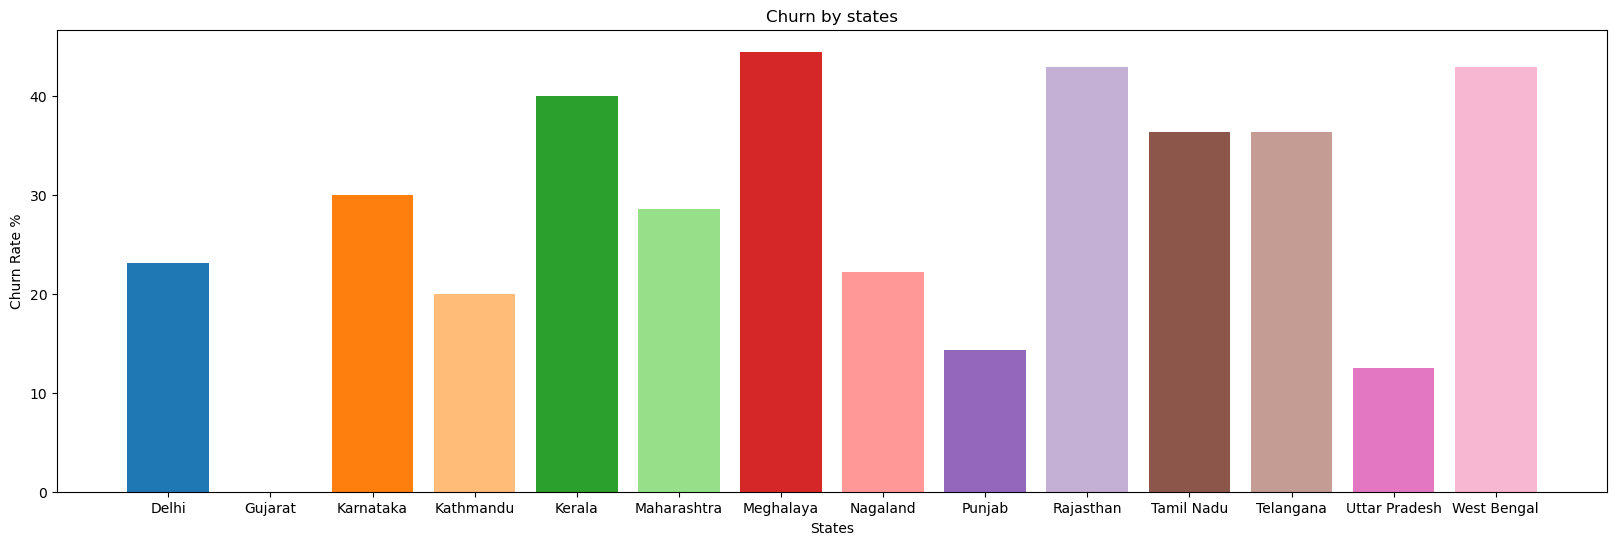

In [274]:
#churn by states
churn_by_states = round(df_visuals.groupby('state')['churn'].mean()*100,2)

plt.figure(figsize=(20,6))
plt.bar(churn_by_states.index, churn_by_states.values, color=plt.cm.tab20(range(len(churn_by_states))))
plt.title('Churn by states')
plt.xlabel('States')
plt.ylabel('Churn Rate %')

In [275]:
#Heatmap correlation matrix
# Encoding - based on priority
df_encoded = df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [278]:
df_visuals[['plan_type', 'contract_type', 'churn_score', 'churn', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [279]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

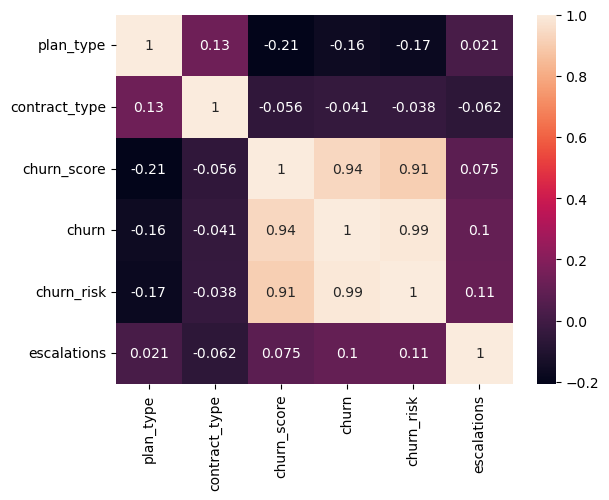

In [281]:
sns.heatmap(df_encoded.corr(), annot= True)

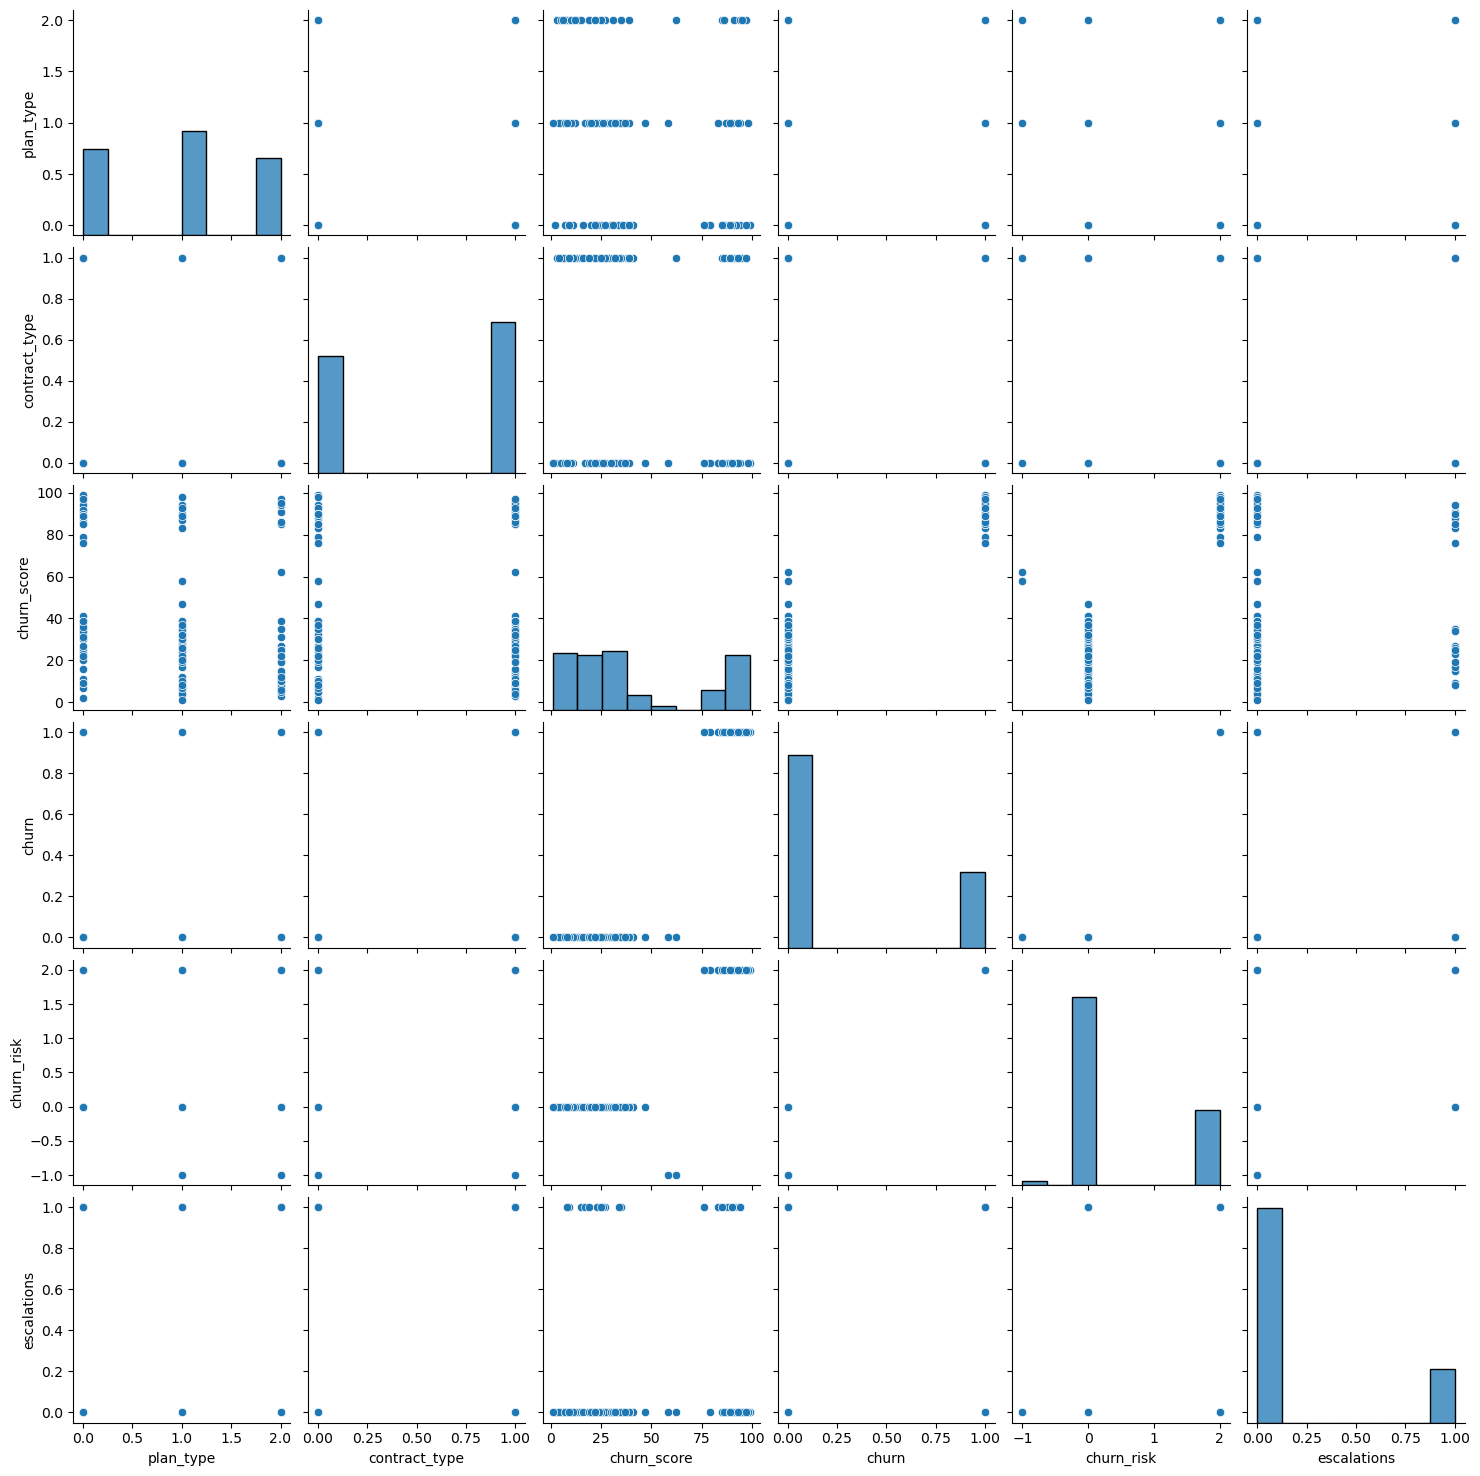

In [282]:
#Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

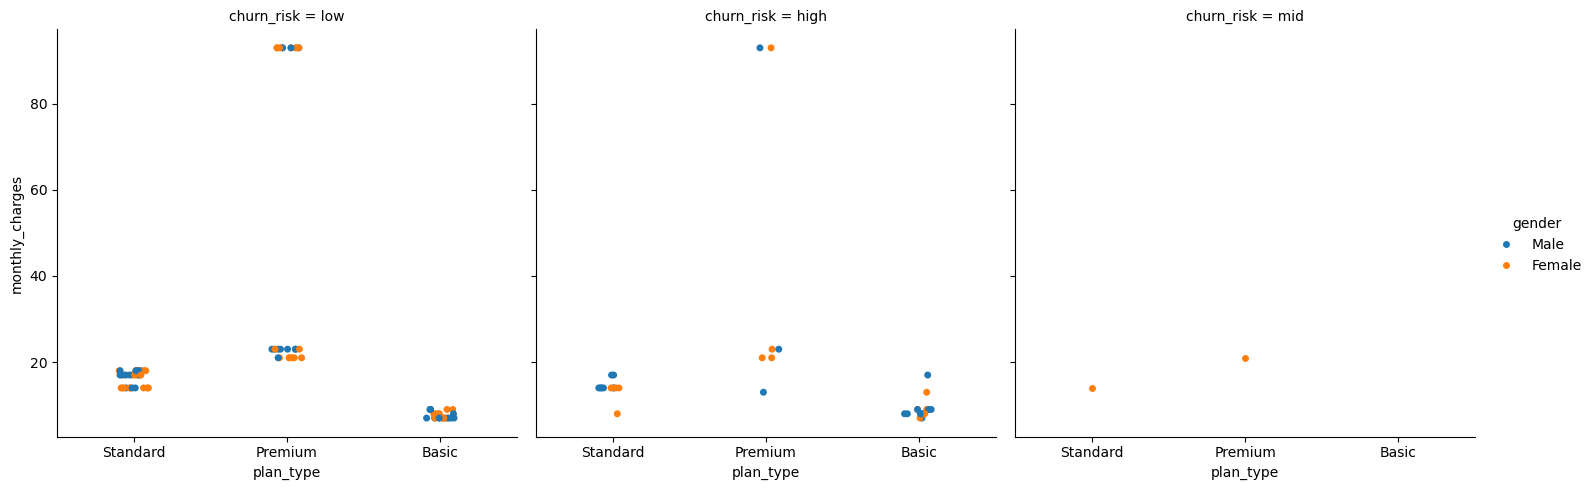

In [284]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visuals,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [287]:
# Pivot Table

pd.pivot_table(
    df_visuals,
    index='plan_type',
    values='churn',
    aggfunc = 'mean'
)

,churn
plan_type,
Basic,0.384615
Premium,0.200000
Standard,0.255319


In [290]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visuals,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn' : 'mean'
    }
)

,churn,customerid,monthly_charges
plan_type,,,
Basic,0.384615,39,320.61
Premium,0.200000,35,1684.65
Standard,0.255319,47,738.53
